# **Регрессия для CC50**

**Импортируем необходимые библиотеки**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

**Загружаем данные**

In [ ]:
df = pd.read_csv('https://raw.githubusercontent.com/nezhablack/project-on-drug-effictiveness/refs/heads/main/chemical_data.csv')

targets_to_exclude = [
    'IC50, mM', 'CC50, mM', 'SI', 'pIC50', 'pCC50', 'log_SI',
    'IC50_above_median', 'CC50_above_median', 'SI_above_median', 'SI_above_8'
]

X = df.drop(columns = targets_to_exclude)
y = df['pCC50']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

print(f'Train: X = {X_train.shape}, y = {y_train.shape}')
print(f'Test : X = {X_test.shape}, y = {y_test.shape}')
print(f'Целевая переменная pCC50:')
print(f'Mean = {y.mean():.3f}, Std = {y.std():.3f}, Min = {y.min():.3f}, Max = {y.max():.3f}')

Train: X = (800, 139), y = (800,)
Test : X = (201, 139), y = (201,)
Целевая переменная pCC50:
Mean = -2.407 Std = 0.716 Min = -3.657 Max = 0.154


Вывод: строим модели для прогнозирования цитотоксичности химических соединений на основе структурных дескрипторов. Целевой переменной выбрали логарифмированную CC50. Потому что так распределение приближается к нормальному, зависимости линеаризуются. Это позволит моделям корректно обрабатывать данные.

**Обучение базовых моделей и подбор гиперпараметров**

In [11]:
pipelines = {
    'Ridge': Pipeline([
        ('scaler', StandardScaler()),
        ('model', Ridge())
    ]),
    'SVR': Pipeline([
        ('scaler', StandardScaler()),
        ('model', SVR())
    ]),
    'RandomForest': Pipeline([
        ('scaler', StandardScaler()),
        ('model', RandomForestRegressor(random_state=42, n_jobs=-1))
    ])
}

param_grids = {
    'Ridge': {
        'model__alpha': [0.1, 1.0, 10.0, 50.0, 100.0, 200.0]
    },
    'SVR': {
        'model__C': [0.1, 1, 10],
        'model__kernel': ['rbf', 'linear'],
        'model__gamma': ['scale', 'auto']
    },
    'RandomForest': {
        'model__n_estimators': [100, 200],
        'model__max_depth': [None, 10, 20],
        'model__min_samples_split': [2, 5]
    }
}

results = []
best_models = {}

print('Обучение моделей (GridSearchCV, cv=5)')

for name in pipelines:
    gs = GridSearchCV(
        pipelines[name], param_grids[name],
        cv = 5, scoring = 'neg_mean_squared_error', n_jobs = -1
    )
    gs.fit(X_train, y_train)
    best_models[name] = gs.best_estimator_

    y_pred = gs.best_estimator_.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)

    results.append({
        'Модель': name,
        'Лучшие гиперпараметры': str(gs.best_params_),
        'R^2': round(r2, 4),
        'MSE': round(mse, 4),
        'MAE': round(mae, 4),
    })
    print(f'R^2={r2:.4f}')

results_df = (
    pd.DataFrame(results)
    .sort_values('R^2', ascending = False)
    .reset_index(drop = True)
)

print('Результаты моделей на тестовой выборке (pCC50)')
display(results_df)

Обучение моделей (GridSearchCV, cv=5)
R^2=0.3680
R^2=0.4175
R^2=0.4314
Результаты моделей на тестовой выборке (pCC50)


,Модель,Лучшие гиперпараметры,R^2,MSE,MAE
0,RandomForest,"{'model__max_depth': None, 'model__min_samples...",0.4314,0.2544,0.3550
1,SVR,"{'model__C': 1, 'model__gamma': 'scale', 'mode...",0.4175,0.2606,0.3644
2,Ridge,{'model__alpha': 50.0},0.3680,0.2828,0.4147


Вывод: GridSearchCV с пятикратной кросс-валидацией обеспечивает устойчивую оценку гиперпараметров. Оптимизируем отрицательный MSE (neg_mean_squared_error),
итоговое качество оцениваем по R^2, MSE и MAE на тестовой выборке.

Цитотоксичность CC50 сложнее для предсказания, чем ингибирующая активность IC50, так как определяется широким спектром клеточных механизмов, которые не всегда связанны со структурными дескрипторами молекулы. Это объясняет более низкий коэффициент детерминации.

**Визуализируем базовые модели**

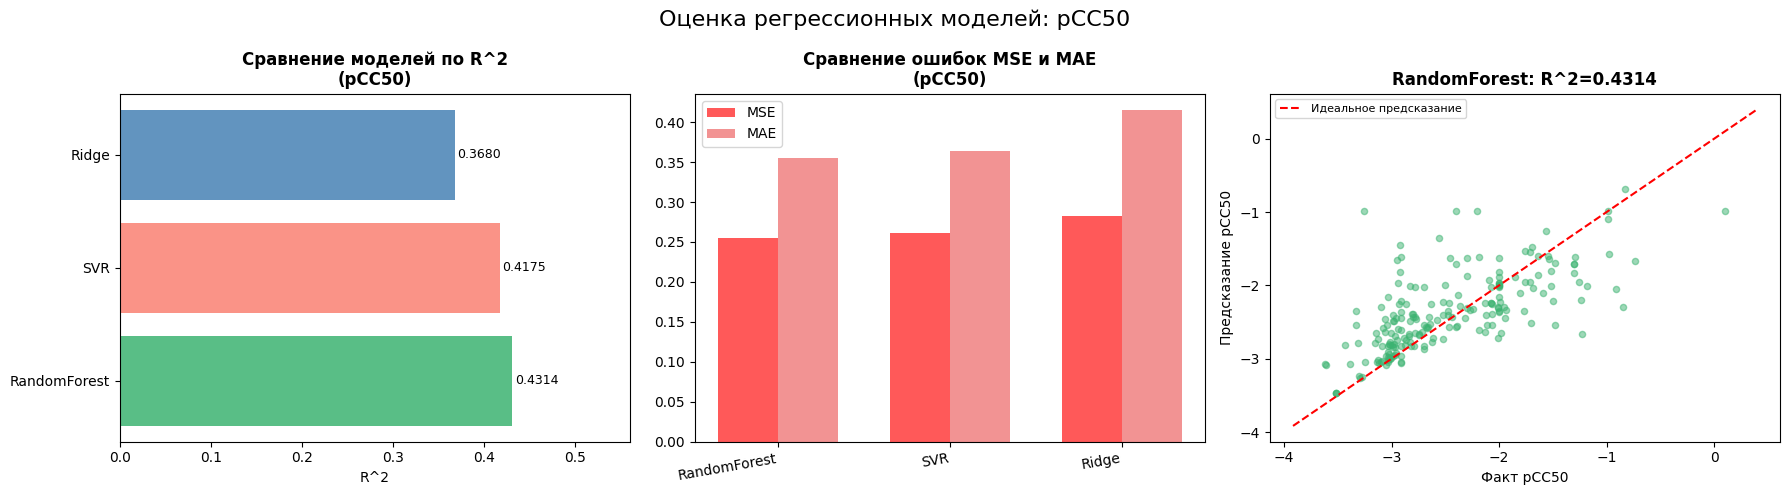

In [ ]:
model_colors = {
    'Ridge': 'steelblue',
    'SVR': 'salmon',
    'RandomForest': 'mediumseagreen'
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.subplots_adjust(wspace=0.35)

#строим график коэффициента детерминации моделей
bars = axes[0].barh(
    results_df['Модель'],
    results_df['R^2'],
    color=results_df['Модель'].map(model_colors),
    alpha=0.85
)
axes[0].set_xlabel('R^2')
axes[0].set_title('Сравнение моделей по R^2 (pCC50)', fontweight = 'bold')
axes[0].set_xlim(0, max(results_df['R^2']) * 1.3)
for bar, val in zip(bars, results_df['R^2']):
    axes[0].text(bar.get_width() + 0.003,
                 bar.get_y() + bar.get_height() / 2,
                 f'{val:.4f}', va='center', fontsize=9)

#строим график MSE и MAE
x = np.arange(len(results_df))
w = 0.35
axes[1].bar(x - w/2, results_df['MSE'], w, label = 'MSE', alpha = 0.65, color = 'red')
axes[1].bar(x + w/2, results_df['MAE'], w, label = 'MAE', alpha = 0.85, color = 'lightcoral')
axes[1].set_xticks(x)
axes[1].set_xticklabels(results_df['Модель'], rotation = 10, ha = 'right')
axes[1].set_title('Сравнение ошибок MSE и MAE (pCC50)', fontweight = 'bold')
axes[1].legend()

#строим график соответствия предсказания лучшей модели факту
best_name = results_df.iloc[0]['Модель']
y_pred_best = best_models[best_name].predict(X_test)

axes[2].scatter(y_test, y_pred_best, alpha=0.5, s = 20, color=model_colors.get(best_name, 'gray'))
lims = [min(y_test.min(), y_pred_best.min()) - 0.3,
        max(y_test.max(), y_pred_best.max()) + 0.3]
axes[2].plot(lims, lims, 'r--', lw=1.5, label='Идеальное предсказание')
axes[2].set_xlabel('Факт pCC50')
axes[2].set_ylabel('Предсказание pCC50')
axes[2].set_title(f'{best_name}: R^2={results_df.iloc[0]["R^2"]:.4f}', fontweight = 'bold')
axes[2].legend(fontsize = 8)

plt.suptitle('Оценка регрессионных моделей: pCC50', fontsize = 16)
plt.tight_layout()
plt.show()

Вывод: модель RandomForest показала лучшие результаты по метрикам ошибок и коэффициенту детерминации. RandomForest улавливает общий тренд, но систематически занижает предсказания для соединений с высоким CC50 и завышает для соединений с низким CC50. Это характерный эффект регрессии к среднему, присущий этому ансамблевому методу. 

**Важность признаков (Random Forest)**

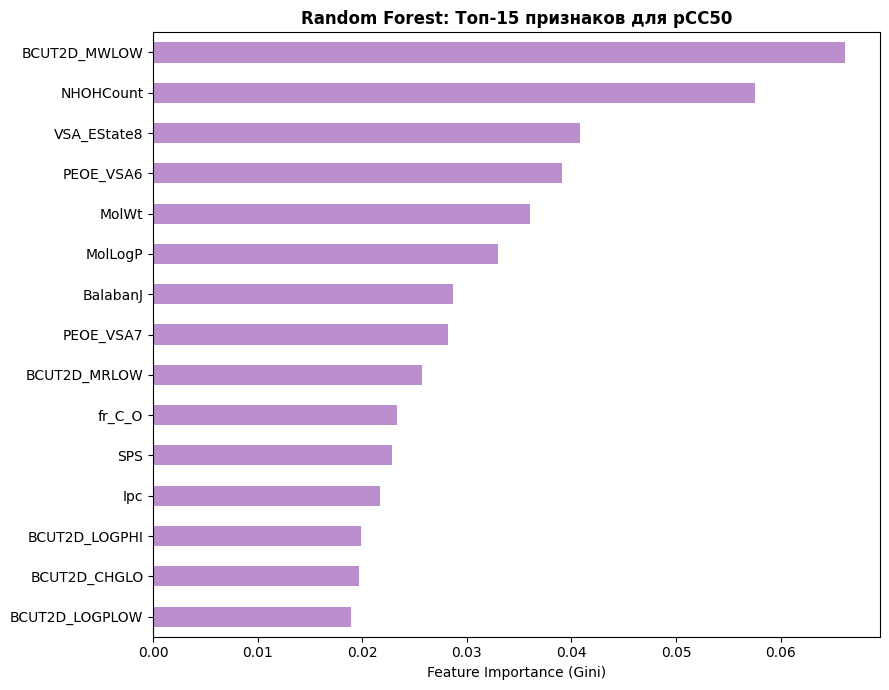

Топ-10 признаков для pCC50:
BCUT2D_MWLOW    0.066194
NHOHCount       0.057509
VSA_EState8     0.040838
PEOE_VSA6       0.039097
MolWt           0.036027
MolLogP         0.032975
BalabanJ        0.028714
PEOE_VSA7       0.028234
BCUT2D_MRLOW    0.025705
fr_C_O          0.023291


In [ ]:
rf_step = best_models['RandomForest'].named_steps['model']
importances = pd.Series(rf_step.feature_importances_, index = X.columns)
top20 = importances.sort_values(ascending = False).head(15)

plt.figure(figsize = (9, 7))
top20[::-1].plot(kind = 'barh', color = 'purple', alpha = 0.85)
plt.xlabel('Feature Importance (Gini)')
plt.title('Random Forest: Топ-15 признаков для pCC50', fontweight = 'bold')
plt.tight_layout()
plt.show()

print('Топ-10 признаков для pCC50:')
print(top20.head(10).to_string())

Вывод: цитотоксичность определяется прежде всего размером и полярностью молекулы - крупные молекулы проникают в клетки и повреждают их. Именно это и отражают топ-признаки. Наибольший вклад у BCUT2D_MWLOW, дескриптора, который кодирует распределение масс атомов с учетом связей. Отражает не просто вес, но и его распределение по молекуле. Второй по весу признак, NHOHCount определяет количество OH и NH групп. Это доноры водородных связей: молекулы с большим числом OH/NH лучше растворимы в воде, хуже проникают через мембрану и менее токсичны (обратная связь с pCC50). Третий признак, VSA_EState8 говорит о вкладе атомов с высоким электротопологическим состоянием в молекулярную поверхность. Чем она выше, тем цитотоксичность повышается.

**Итоговые выводы и рекомендации**

Модель Random Forest показала лучший результат, она эффективно улавливает нелинейные зависимости. Ridge значительно уступает SVR и RF, что подтверждает гипотезу: зависимость между структурными дескрипторами и цитотоксичностью носит нелинейный характер. Потолок R^2 на уровне 0.43 обусловлен, вероятнее всего, не алгоритмами, а природой задачи: цитотоксичность определяется множеством клеточных механизмов, которые кодируются структурными дескрипторами не полностью.

SVR и Random Forest демонстрируют сопоставимое качество при принципиально разной математической природе - это указывает на то, что оба алгоритма извлекают схожие, но дополняющие друг друга закономерности.

В качестве оптимального инструмента выбран Random Forest Regressor. У него есть устойчивость к переобучению и интерпретируемость через feature importance.

Рекомендации по улучшению:

- собрать побольше данных. Соотношение объектов к признакам 800 / 139 = 5.7 ниже рекомендуемого минимума 10:1. Расширение выборки - наиболее действенный способ поднять R^2
- удалить коррелирующие дескрипторов на основе RF importance, оставить топ-40-60 признаков. Это снизит шум и улучшит точность
- создать новые признаки в виде попарных произведений топ-10 признаков и логарифмировать скошенные дескрипторы. Это позволит Ridge увидеть нелинейные зависимости
- объединение RF и SVR, поскольку оба алгоритма ошибаются по-разному - их ошибки некоррелированы, что создает условия для синергетического эффекта